# Kaggle Validation Dataset Transformation

This notebook prepares the Kaggle validation CSV for the ATS scoring workflow by converting raw fields into structured candidate and job-description text, then computing the derived `ats_score` and `original_label` columns.

It is a data-transformation and validation notebook for the downstream ATS pipeline, not the production inference app itself.

### Phase 1: Ingestion & Smart Feature Concatenation

To ensure the downstream ATS validation pipeline receives contextually rich inputs, we transform fragmented CSV columns into structured textual profiles.

**Rationale:** Rather than simple concatenation, we use explicit semantic headers (e.g., `Skills:`, `Experience:`) and newlines. This structural metadata helps the later scoring logic distinguish between candidate attributes. We apply `.fillna('')` to prevent the literal string 'nan' from contaminating the feature space.

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, mean_absolute_error

# Load the Kaggle validation dataset
file_path = '/content/drive/MyDrive/Deblina-Projects/NLP-PROJECT/Data/validation_dataset_kaggle.csv'
df_kaggle = pd.read_csv(file_path)

# Cleanse NaNs to prevent string contamination
df_kaggle = df_kaggle.fillna('')

# Construct candidate_resume_text with structural prefixes
def construct_resume(row):
    return (f"Resume Text: {row['resume_text']}\n"
            f"Skills: {row['resume_skills']}\n"
            f"Experience: {row['experience_years']} Years\n"
            f"Education: {row['education_level']}\n"
            f"Projects: {row['projects']}\n"
            f"Certifications: {row['certifications']}")

# Construct target_job_description with structural prefixes
def construct_jd(row):
    return (f"Job Role: {row['job_role']}\n"
            f"Required Skills: {row['required_skills']}\n"
            f"Experience Required: {row['job_experience_required']}\n"
            f"Job Description: {row['job_description']}")

df_kaggle['candidate_resume_text'] = df_kaggle.apply(construct_resume, axis=1)
df_kaggle['target_job_description'] = df_kaggle.apply(construct_jd, axis=1)

print(f"Successfully processed {len(df_kaggle)} records.")
display(df_kaggle[['candidate_resume_text', 'target_job_description']].head(2))

Successfully processed 6000 records.


,candidate_resume_text,target_job_description
0,Resume Text: Professional Summary:\nCandidate ...,Job Role: Software Engineer\nRequired Skills: ...
1,Resume Text: Professional Summary:\nCandidate ...,Job Role: Data Scientist\nRequired Skills: Doc...


### Phase 2: Ground Truth Transformation & Synthesis

We synthesize multiple disparate metrics into a unified ATS score stored in `ats_score`. The score is calculated with the same weighted linear combination used in the code, with higher weight on skills and similarity.

**Mathematical Formula:**
$$\text{ATS Score} = \left( 0.40(S_{skill}) + 0.30(S_{sim}) + 0.15(M_{exp}) + 0.05(M_{edu}) + 0.10(S_{final}) \right) \times 100$$

**Business Logic for Fit Category:**
The notebook uses the `shortlisted` flag together with the computed score to assign `Good Fit`, `Potential Fit`, or `No Fit`. In this implementation, a score of at least 75 with `shortlisted == 1` becomes `Good Fit`; scores in the 50-75 range, or any `shortlisted == 1` case below 75, become `Potential Fit`; otherwise the label is `No Fit`.

In [17]:
import os

def calculate_ground_truth(row):
    # Calculate weighted continuous score based on the LaTeX formula provided
    score = (
        0.40 * float(row['skill_match_score']) +
        0.30 * float(row['similarity_score']) +
        0.15 * float(row['experience_match']) +
        0.05 * float(row['education_match']) +
        0.10 * float(row['final_score'])
    ) * 100

    # Determine categorical fit using the 'original_label' taxonomy
    shortlisted = int(row['shortlisted'])
    if score >= 75 and shortlisted == 1:
        label = "Good Fit"
    elif (50 <= score < 75) or (shortlisted == 1 and score < 75):
        label = "Potential Fit"
    else:
        label = "No Fit"

    return pd.Series([score, label])

# Apply transformation and create the requested validation columns
df_kaggle[['ats_score', 'original_label']] = df_kaggle.apply(calculate_ground_truth, axis=1)

# Filter to keep only the 5 specific columns requested
columns_to_keep = [
    'candidate_resume_text',
    'target_job_description',
    'ats_score',
    'original_label'
]
df_final = df_kaggle[columns_to_keep].copy()

# Updated output path to Google Drive
output_path = '/content/drive/MyDrive/Deblina-Projects/NLP-PROJECT/Data/validation_dataset_kaggle_transformed.csv'

# Ensure the directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the filtered transformed dataset
df_final.to_csv(output_path, index=False)

print(f"Transformation complete. Filtered dataset (5 columns) saved to {output_path}")
display(df_final.head())

Transformation complete. Filtered dataset (5 columns) saved to /content/drive/MyDrive/Deblina-Projects/NLP-PROJECT/Data/validation_dataset_kaggle_transformed.csv


,candidate_resume_text,target_job_description,ats_score,original_label
0,Resume Text: Professional Summary:\nCandidate ...,Job Role: Software Engineer\nRequired Skills: ...,74.037906,Potential Fit
1,Resume Text: Professional Summary:\nCandidate ...,Job Role: Data Scientist\nRequired Skills: Doc...,49.852143,Potential Fit
2,Resume Text: Professional Summary:\nCandidate ...,Job Role: ML Engineer\nRequired Skills: Docker...,54.195982,Potential Fit
3,Resume Text: Professional Summary:\nCandidate ...,Job Role: Data Scientist\nRequired Skills: PyT...,71.795975,Potential Fit
4,Resume Text: Professional Summary:\nCandidate ...,"Job Role: Data Analyst\nRequired Skills: Java,...",65.934723,Potential Fit


In [18]:
label_distribution = df_final['original_label'].value_counts()
label_percentage = df_final['original_label'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': label_distribution,
    'Percentage (%)': label_percentage
})

print("Distribution of 'original_label':")
display(distribution_df)

Distribution of 'original_label':


,Count,Percentage (%)
original_label,,
Potential Fit,4287,71.450000
No Fit,1004,16.733333
Good Fit,709,11.816667


In [19]:
# Calculate mean ats_score for each category
mean_scores = df_final.groupby('original_label')['ats_score'].mean().sort_values(ascending=False).reset_index()

print("Mean ATS Score by Original Label:")
display(mean_scores)

Mean ATS Score by Original Label:


,original_label,ats_score
0,Good Fit,80.653274
1,Potential Fit,61.633816
2,No Fit,42.256322


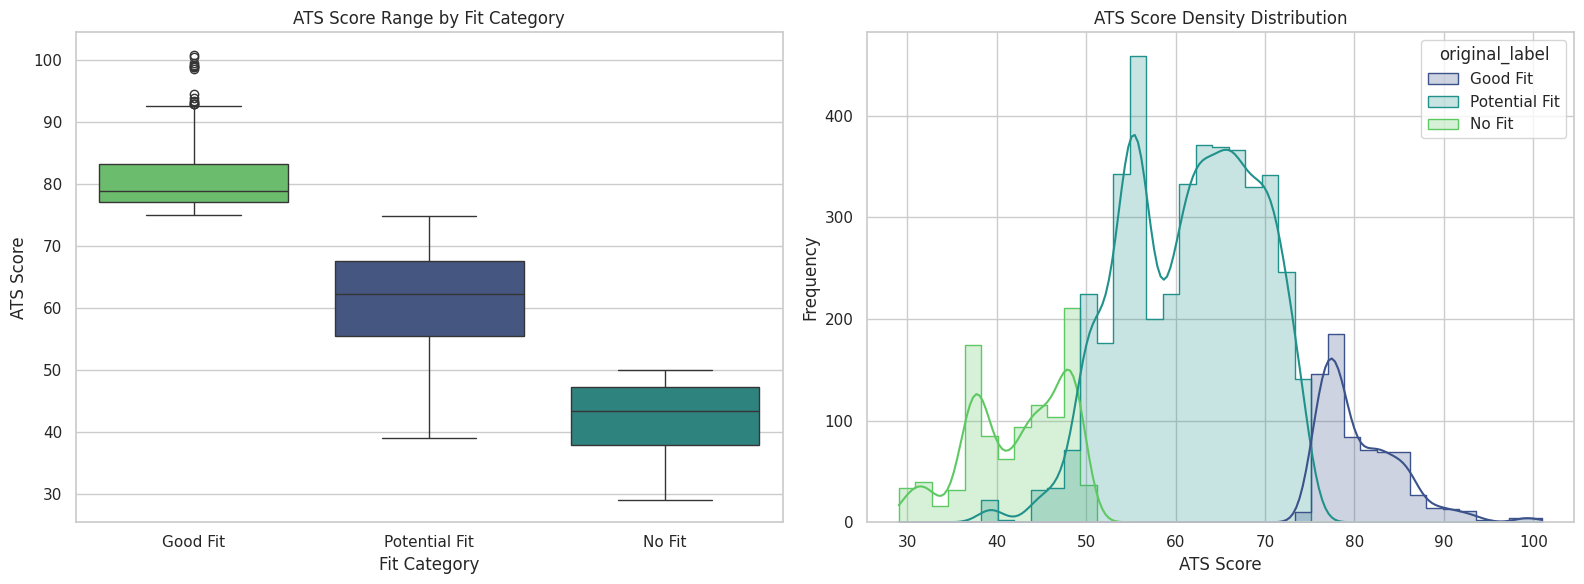

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot to show quartiles and outliers
sns.boxplot(
    data=df_final,
    x='original_label',
    y='ats_score',
    order=['Good Fit', 'Potential Fit', 'No Fit'],
    palette='viridis',
    ax=axes[0],
    hue='original_label',
    legend=False
)
axes[0].set_title('ATS Score Range by Fit Category')
axes[0].set_xlabel('Fit Category')
axes[0].set_ylabel('ATS Score')

# 2. Histograms/KDE to show density distribution
sns.histplot(
    data=df_final,
    x='ats_score',
    hue='original_label',
    hue_order=['Good Fit', 'Potential Fit', 'No Fit'],
    kde=True,
    element='step',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('ATS Score Density Distribution')
axes[1].set_xlabel('ATS Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Phase 3: Final Dataset Statistics & Integrity Report

This section provides a high-level overview of the transformed dataset to ensure data integrity before further modeling or inference.

In [21]:
# 1. Dataset Overview (Shapes and Types)
print("--- Dataset Information ---")
display(df_final.info())

# 2. Descriptive Statistics for Numerical Scores
print("\n--- ATS Score Descriptive Statistics ---")
display(df_final['ats_score'].describe())

# 3. Check for any missing values
print("\n--- Missing Values Check ---")
print(df_final.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   candidate_resume_text   6000 non-null   object 
 1   target_job_description  6000 non-null   object 
 2   ats_score               6000 non-null   float64
 3   original_label          6000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 187.6+ KB


None


--- ATS Score Descriptive Statistics ---


,ats_score
count,6000.000000
mean,60.638781
std,12.294710
min,29.067278
25%,52.258617
50%,61.531859
75%,69.258668
max,100.946384



--- Missing Values Check ---
candidate_resume_text     0
target_job_description    0
ats_score                 0
original_label            0
dtype: int64
